# WEATHER PREDICTION - COMPLETE PROJECT

### DATA UNDERSTANDING
### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('All libraries imported successfully!')

All libraries imported successfully!


### Load Dataset

Note: Naming of the columns is also fixed here.

In [2]:
df = pd.read_csv('open-meteo-cesena.csv')

# FIX: Clean column names (replace encoding issues)
df.columns = df.columns.str.replace('Â°', '°')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print('\nColumn names:')
for col in df.columns:
    print(f'- {col}')
df.head()

Dataset loaded successfully!
Shape: (5844, 13)

Column names:
- time
- temperature_2m (°C)
- precipitation (mm)
- surface_pressure (hPa)
- pressure_msl (hPa)
- wind_speed_10m (km/h)
- soil_temperature_0_to_7cm (°C)
- relative_humidity_2m (%)
- dew_point_2m (°C)
- apparent_temperature (°C)
- wind_direction_10m (°)
- wind_gusts_10m (km/h)
- cloud_cover (%)


,time,temperature_2m (°C),precipitation (mm),surface_pressure (hPa),pressure_msl (hPa),wind_speed_10m (km/h),soil_temperature_0_to_7cm (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),wind_direction_10m (°),wind_gusts_10m (km/h),cloud_cover (%)
0,2022-01-01T00:00,2.0,0.0,1019.7,1025.7,5.2,4.0,100,2.0,-0.6,282,9.4,100
1,2022-01-01T06:00,1.5,0.0,1019.6,1025.6,3.4,3.3,100,1.5,-0.9,238,8.6,100
2,2022-01-01T12:00,6.9,0.0,1021.5,1027.4,3.6,5.8,75,2.8,4.8,360,14.4,100
3,2022-01-01T18:00,3.2,0.0,1020.5,1026.4,3.1,5.2,100,3.2,1.1,225,9.0,100
4,2022-01-02T00:00,3.5,0.0,1022.0,1027.9,2.4,4.2,85,1.3,1.3,243,9.7,100


### Data Info

In [3]:
print('Dataset Information:')
df.info()
print('\nMissing Values:')
print(df.isnull().sum())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 5844 entries, 0 to 5843
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   time                            5844 non-null   str    
 1   temperature_2m (°C)             5844 non-null   float64
 2   precipitation (mm)              5844 non-null   float64
 3   surface_pressure (hPa)          5844 non-null   float64
 4   pressure_msl (hPa)              5844 non-null   float64
 5   wind_speed_10m (km/h)           5844 non-null   float64
 6   soil_temperature_0_to_7cm (°C)  5844 non-null   float64
 7   relative_humidity_2m (%)        5844 non-null   int64  
 8   dew_point_2m (°C)               5844 non-null   float64
 9   apparent_temperature (°C)       5844 non-null   float64
 10  wind_direction_10m (°)          5844 non-null   int64  
 11  wind_gusts_10m (km/h)           5844 non-null   float64
 12  cloud_cover (%)         

There is no missing data, therefore there is no need for imputation. However, all data types are numeric except time. It must be converted to date time.

Note: In Colab, 'time' data type is shown as str. In pandas, object and string type are very similar but not the same. Object type uses pointers to store the string variables. Different versions of pandas library can cause different results in colab and jupyter. This difference is not very important in this project.

### Statistical Summary

In [4]:
df.describe()

,temperature_2m (°C),precipitation (mm),surface_pressure (hPa),pressure_msl (hPa),wind_speed_10m (km/h),soil_temperature_0_to_7cm (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),wind_direction_10m (°),wind_gusts_10m (km/h),cloud_cover (%)
count,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000,5844.000000
mean,15.080459,0.599829,1010.563347,1016.211636,8.178730,15.998392,74.864990,9.977105,14.240931,194.911533,17.917813,51.745038
std,8.541100,2.152007,7.745206,7.838003,4.752098,8.504083,18.756702,6.232682,10.116447,93.926903,9.532087,42.813731
min,-4.700000,0.000000,980.000000,985.500000,0.000000,-0.100000,17.000000,-10.900000,-7.900000,1.000000,1.100000,0.000000
25%,8.100000,0.000000,1006.100000,1011.600000,5.100000,8.800000,61.000000,5.400000,6.000000,107.000000,11.200000,4.000000
50%,14.600000,0.000000,1010.400000,1015.900000,7.200000,15.400000,78.000000,10.200000,13.600000,219.000000,15.800000,50.000000
75%,21.400000,0.100000,1015.025000,1020.700000,10.200000,22.500000,92.000000,15.100000,22.300000,270.000000,22.700000,100.000000
max,39.700000,26.400000,1034.400000,1040.400000,46.500000,36.500000,100.000000,24.900000,38.800000,360.000000,85.300000,100.000000


---
## Feature Engineering
### Create Temporal Features
**Extracting year, month, day, hour and creating season column**

In [5]:
# Convert time to datetime
df['time'] = pd.to_datetime(df['time'])

# Extract temporal features
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['hour'] = df['time'].dt.hour
df['day_of_week'] = df['time'].dt.dayofweek

# Create season column
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['season'] = df['month'].apply(get_season)

print(f'\nDataset shape: {df.shape}')
df.head()


Dataset shape: (5844, 19)


,time,temperature_2m (°C),precipitation (mm),surface_pressure (hPa),pressure_msl (hPa),wind_speed_10m (km/h),soil_temperature_0_to_7cm (°C),relative_humidity_2m (%),dew_point_2m (°C),apparent_temperature (°C),wind_direction_10m (°),wind_gusts_10m (km/h),cloud_cover (%),year,month,day,hour,day_of_week,season
0,2022-01-01 00:00:00,2.0,0.0,1019.7,1025.7,5.2,4.0,100,2.0,-0.6,282,9.4,100,2022,1,1,0,5,Winter
1,2022-01-01 06:00:00,1.5,0.0,1019.6,1025.6,3.4,3.3,100,1.5,-0.9,238,8.6,100,2022,1,1,6,5,Winter
2,2022-01-01 12:00:00,6.9,0.0,1021.5,1027.4,3.6,5.8,75,2.8,4.8,360,14.4,100,2022,1,1,12,5,Winter
3,2022-01-01 18:00:00,3.2,0.0,1020.5,1026.4,3.1,5.2,100,3.2,1.1,225,9.0,100,2022,1,1,18,5,Winter
4,2022-01-02 00:00:00,3.5,0.0,1022.0,1027.9,2.4,4.2,85,1.3,1.3,243,9.7,100,2022,1,2,0,6,Winter


---
## Exploratory Data Analysis
### Temperature Distribution
**Visualizing temperature distribution with histogram and boxplot by year**

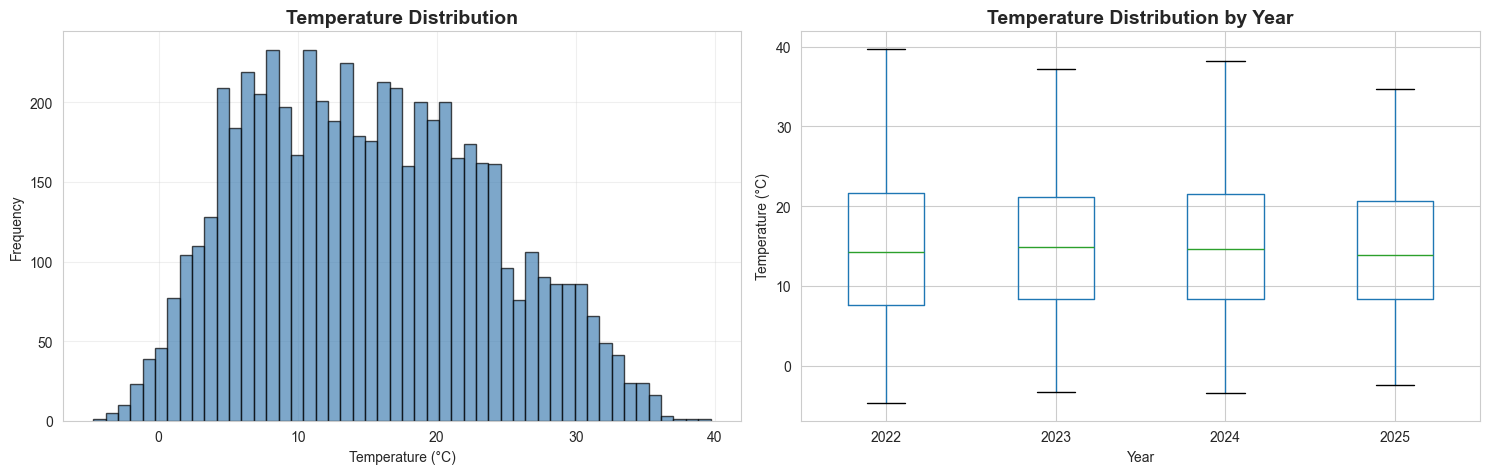

Temperature range: -4.7°C to 39.7°C
Mean temperature: 15.1°C
Median temperature: 14.6°C


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['temperature_2m (°C)'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_title('Temperature Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

# Boxplot by year
df.boxplot(column='temperature_2m (°C)', by='year', ax=axes[1])
axes[1].set_title('Temperature Distribution by Year', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Temperature (°C)')
plt.suptitle('')

plt.tight_layout()
plt.show()

print(f"Temperature range: {df['temperature_2m (°C)'].min():.1f}°C to {df['temperature_2m (°C)'].max():.1f}°C")
print(f"Mean temperature: {df['temperature_2m (°C)'].mean():.1f}°C")
print(f"Median temperature: {df['temperature_2m (°C)'].median():.1f}°C")

### Temperature Over Time
**Time series visualization of temperature trends**

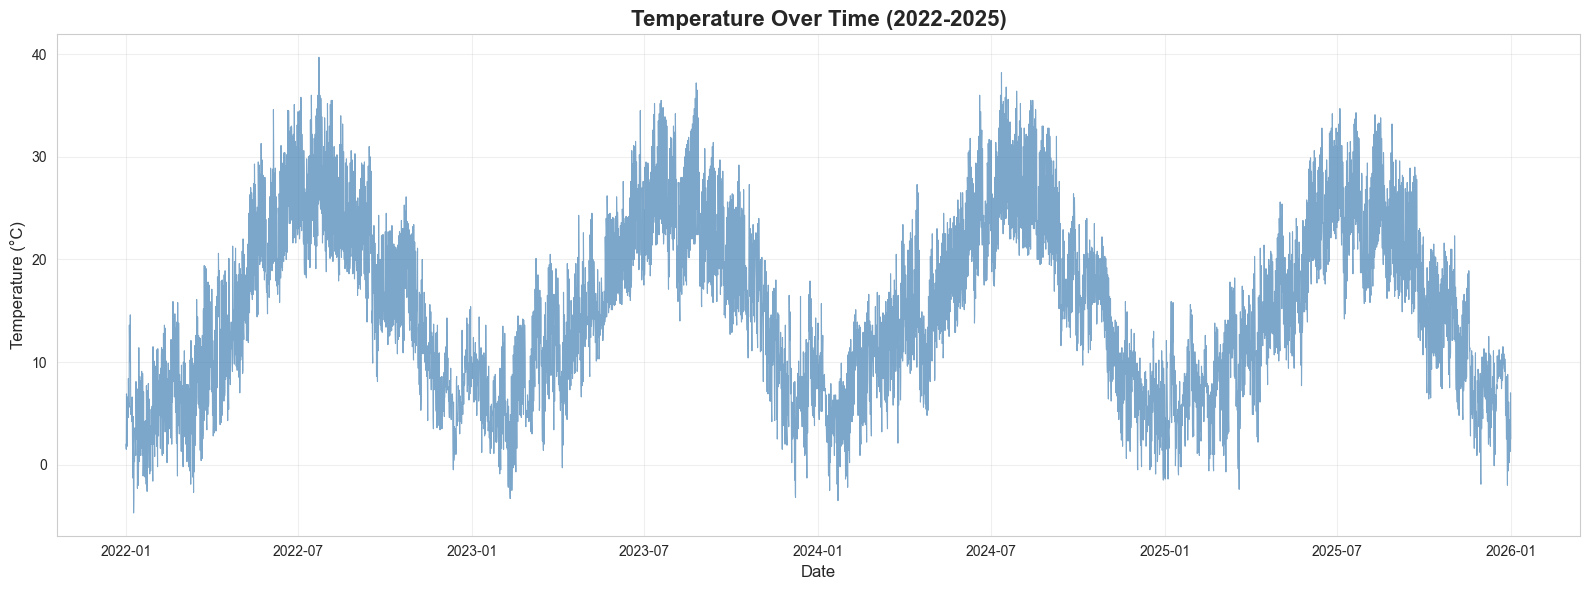

In [7]:
plt.figure(figsize=(16, 6))
plt.plot(df['time'], df['temperature_2m (°C)'], alpha=0.7, linewidth=0.8, color='steelblue')
plt.title('Temperature Over Time (2022-2025)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

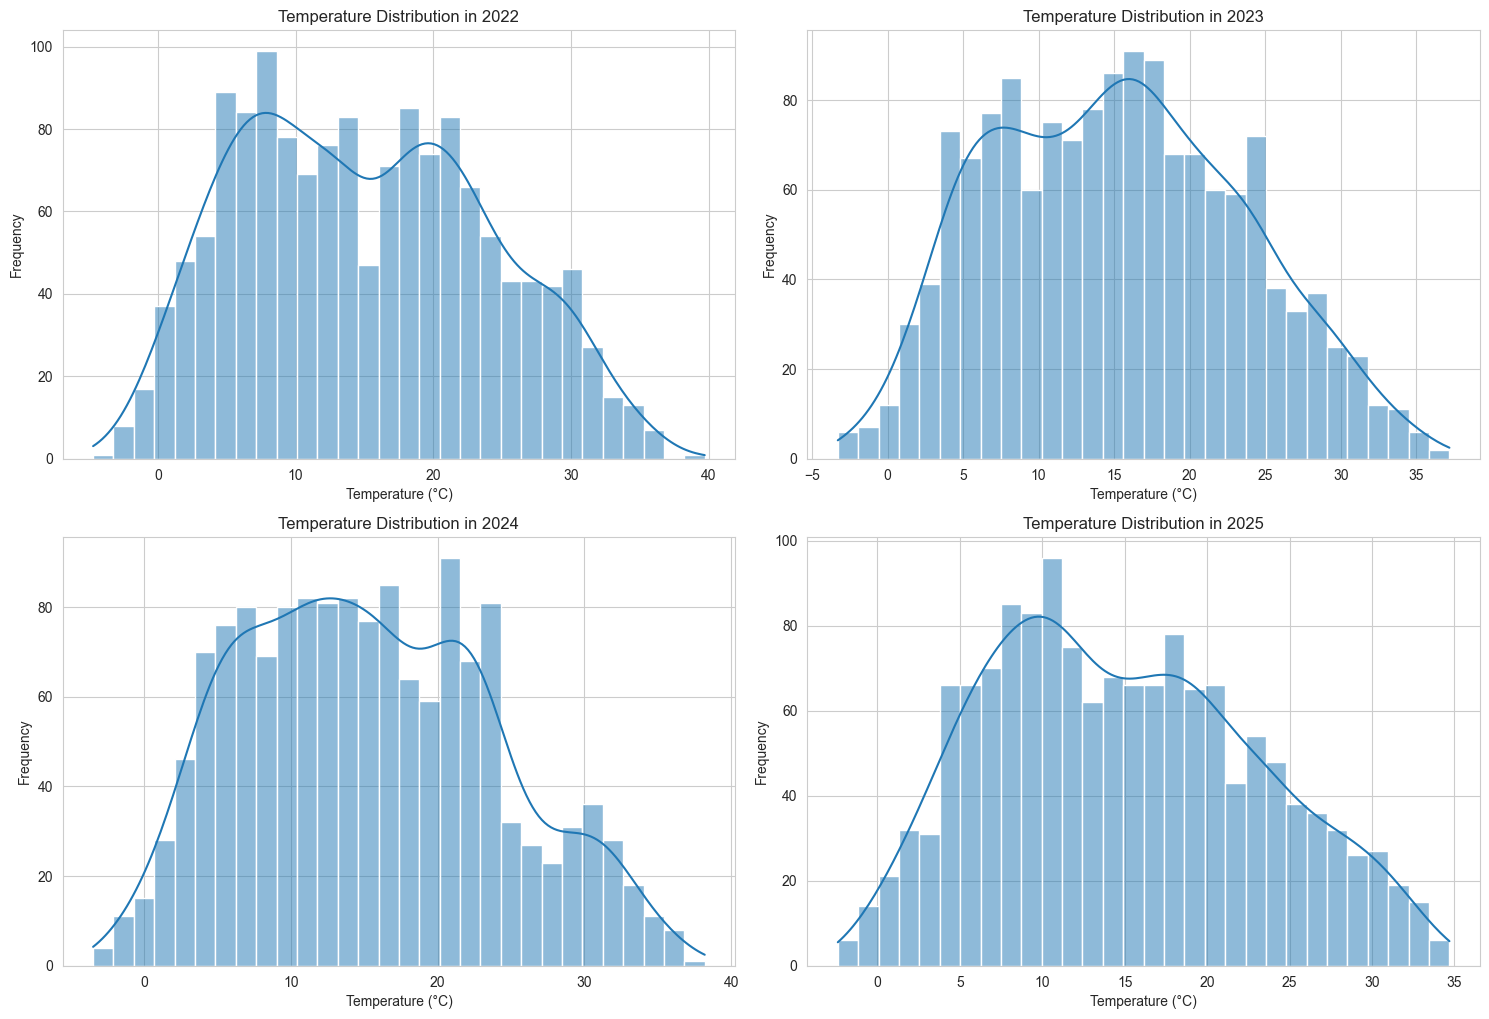

In [8]:
# Get unique years for iteration
years = df['year'].unique().tolist()
years.sort()

plt.figure(figsize=(15, 5 * len(years)))

for i, year in enumerate(years):
    plt.subplot(len(years), 2, i + 1)
    sns.histplot(df[df['year'] == year]['temperature_2m (°C)'], kde=True, bins=30)
    plt.title(f'Temperature Distribution in {year}')
    plt.xlabel('Temperature (°C)')
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Temperature by Season
**Seasonal analysis with boxplot and statistics**

In [9]:
df_monthly_avg = df.groupby(['year', 'month'])['temperature_2m (°C)'].mean().reset_index()
display(df_monthly_avg.head())

,year,month,temperature_2m (°C)
0,2022,1,3.598387
1,2022,2,6.880357
2,2022,3,7.104839
3,2022,4,11.798333
4,2022,5,19.641935


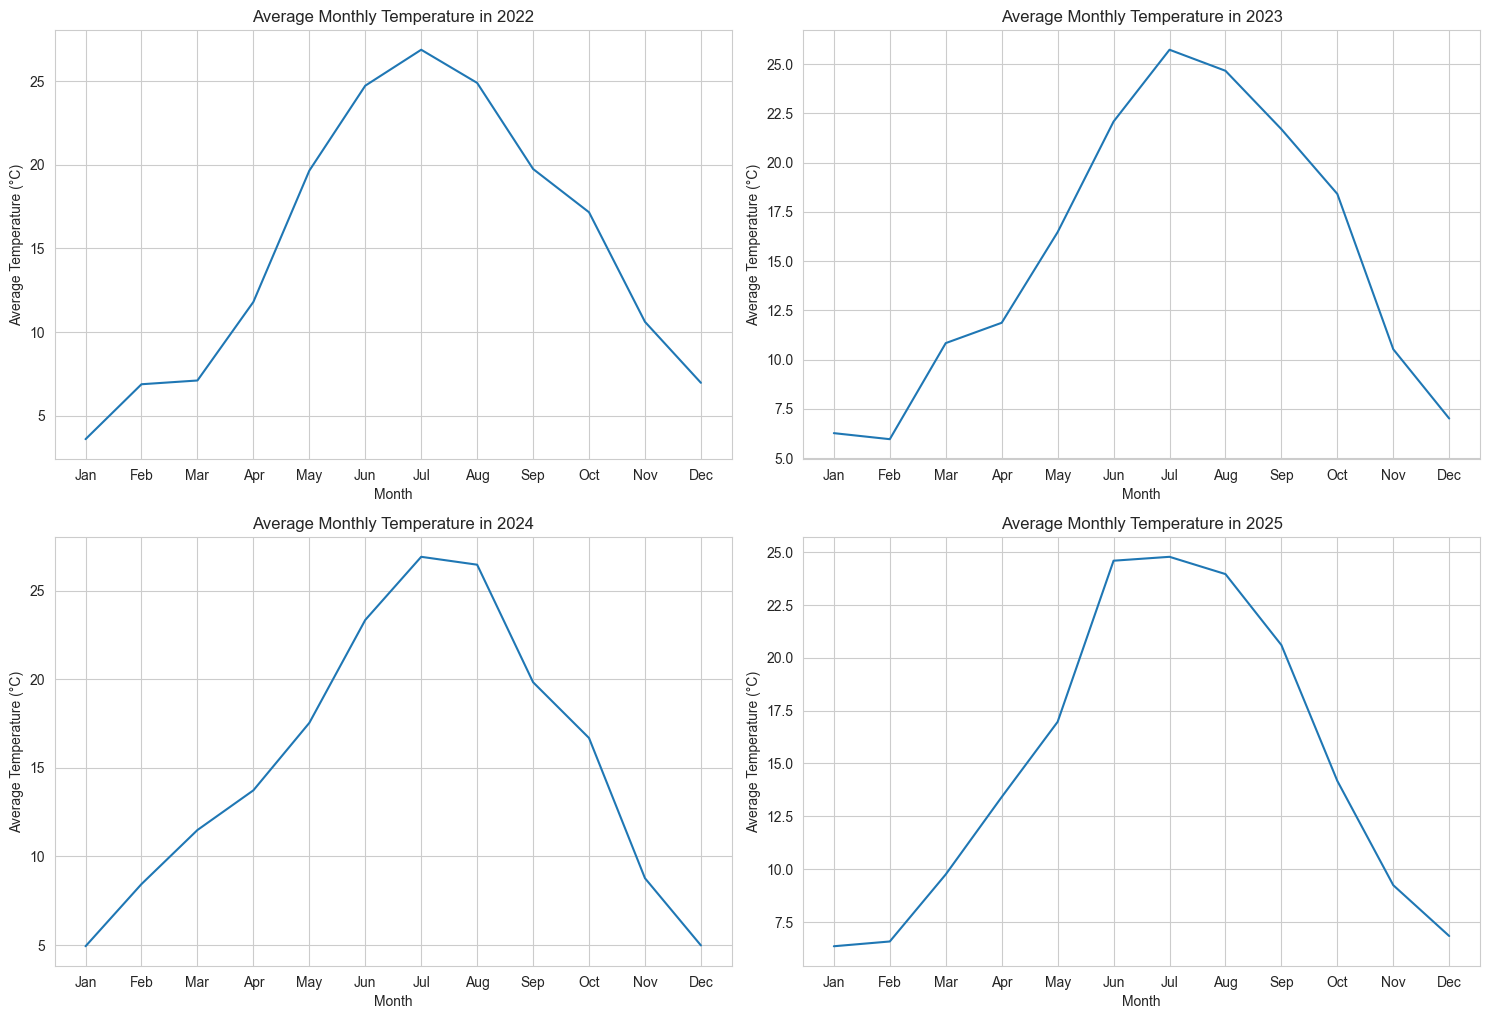

In [10]:
plt.figure(figsize=(15, 5 * len(years)))

for i, year in enumerate(years):
    plt.subplot(len(years), 2, i + 1)
    sns.lineplot(data=df_monthly_avg[df_monthly_avg['year'] == year], x='month', y='temperature_2m (°C)')
    plt.title(f'Average Monthly Temperature in {year}')
    plt.xlabel('Month')
    plt.ylabel('Average Temperature (°C)')
    plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    plt.grid(True)

plt.tight_layout()
plt.show()

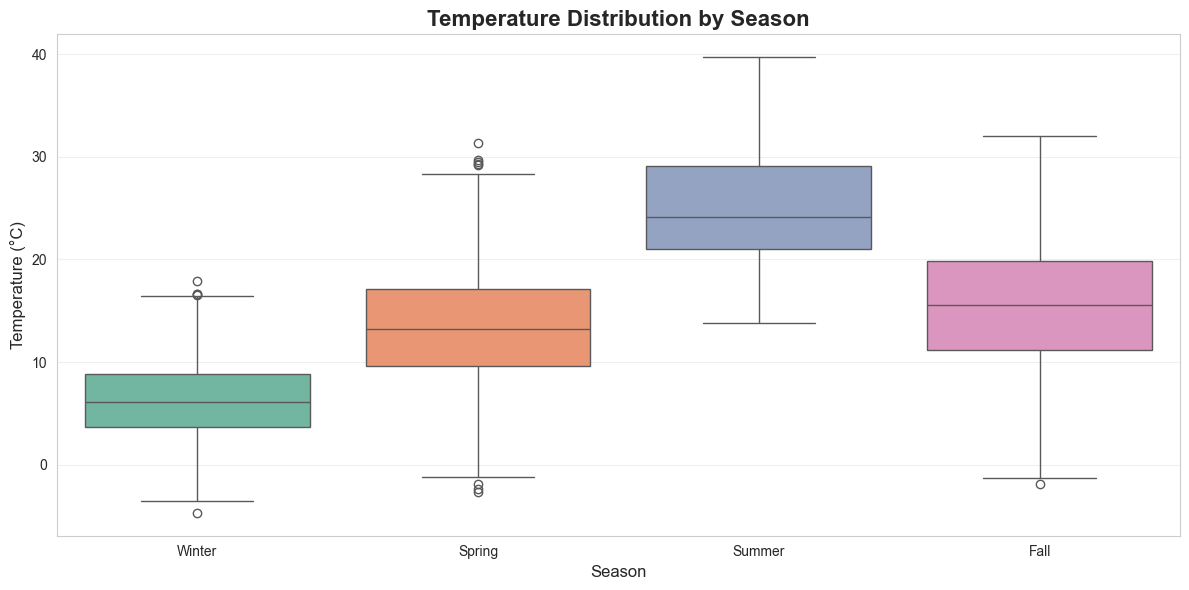


Temperature Statistics by Season:
         count       mean       std   min     25%   50%   75%   max
season                                                             
Fall    1456.0  15.628434  6.229697  -1.9  11.200  15.6  19.8  32.0
Spring  1472.0  13.389878  5.809185  -2.7   9.575  13.2  17.1  31.3
Summer  1472.0  24.928261  5.064352  13.8  21.000  24.1  29.1  39.7
Winter  1444.0   6.212535  3.856294  -4.7   3.700   6.1   8.8  17.9


In [11]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='season', y='temperature_2m (°C)', 
            order=['Winter', 'Spring', 'Summer', 'Fall'],
            palette='Set2')
plt.title('Temperature Distribution by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('\nTemperature Statistics by Season:')
print(df.groupby('season')['temperature_2m (°C)'].describe())

We can observe there are some outliers. We can keep or remove them. It is depending on us.

### Correlation Matrix
**IMPORTANT! Analyzing feature correlations to decide which features to keep/remove**

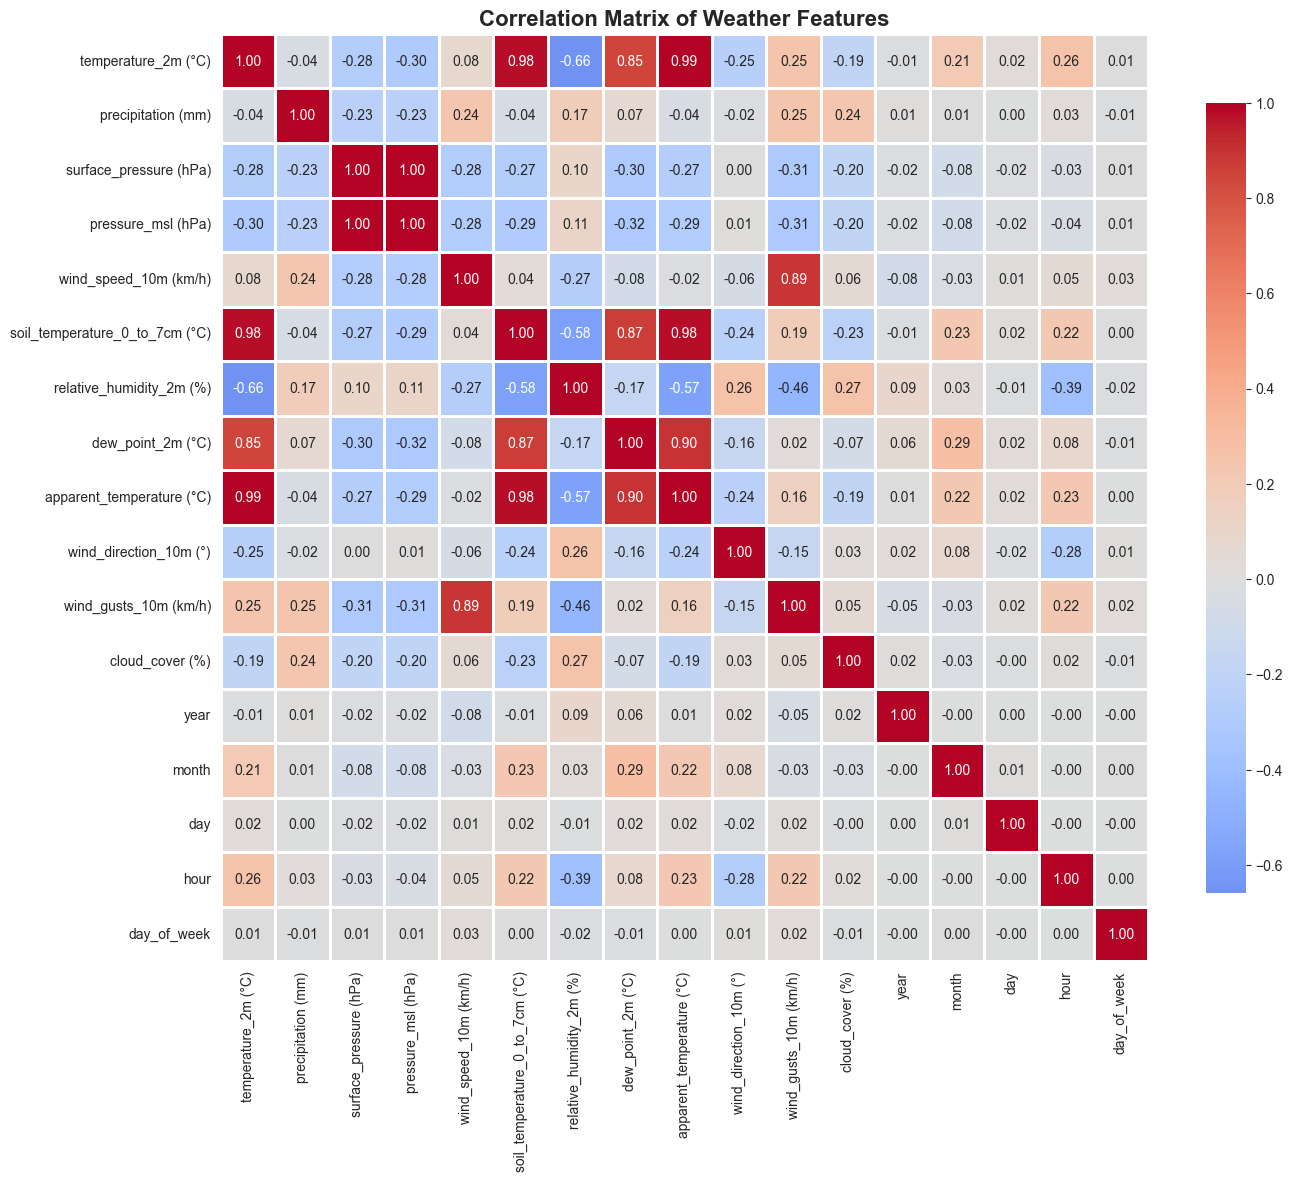

CORRELATION WITH TEMPERATURE (Target Variable)
temperature_2m (°C)               1.000000
apparent_temperature (°C)         0.991354
soil_temperature_0_to_7cm (°C)    0.977384
dew_point_2m (°C)                 0.847713
hour                              0.262744
wind_gusts_10m (km/h)             0.253353
month                             0.206070
wind_speed_10m (km/h)             0.075985
day                               0.023036
day_of_week                       0.005377
year                             -0.007874
precipitation (mm)               -0.036899
cloud_cover (%)                  -0.192174
wind_direction_10m (°)           -0.252220
surface_pressure (hPa)           -0.281981
pressure_msl (hPa)               -0.301418
relative_humidity_2m (%)         -0.658173
Name: temperature_2m (°C), dtype: float64
HIGHLY CORRELATED FEATURE PAIRS (>0.9)
temperature_2m (°C) <-> soil_temperature_0_to_7cm (°C): 0.977
temperature_2m (°C) <-> apparent_temperature (°C): 0.991
surface_pressure (hPa)

In [12]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns

correlation = df[numeric_cols].corr()

# Visualize correlation matrix
plt.figure(figsize=(14, 12))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of Weather Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Show correlation with temperature specifically
print('CORRELATION WITH TEMPERATURE (Target Variable)')
temp_corr = correlation['temperature_2m (°C)'].sort_values(ascending=False)
print(temp_corr)

print('HIGHLY CORRELATED FEATURE PAIRS (>0.9)')
high_corr_pairs = []
for i in range(len(correlation.columns)):
    for j in range(i+1, len(correlation.columns)):
        if abs(correlation.iloc[i, j]) > 0.9:
            high_corr_pairs.append((correlation.columns[i], correlation.columns[j], correlation.iloc[i, j]))

for pair in high_corr_pairs:
    print(f"{pair[0]} <-> {pair[1]}: {pair[2]:.3f}")

### Feature Selection Decision
**Documenting which features to keep/remove based on correlation analysis**

Features to REMOVE:
1. 'apparent_temperature' - Derived from temperature (multicollinearity)
2. 'dew_point_2m' - Highly correlated with temperature
3. 'soil_temperature_0_to_7cm' - Very similar to air temperature
4. 'time' - We extracted features from it (year, month, hour, etc.)
5. 'surface_pressure' - Keep only pressure_msl (they're almost identical)
6. 'year', 'day' - Not useful for prediction (too specific)

Features to KEEP:
1. precipitation (mm)
2. pressure_msl (hPa)
3. wind_speed_10m (km/h)
4. wind_direction_10m (°)
5. wind_gusts_10m (km/h)
6. relative_humidity_2m (%)
7. cloud_cover (%)
8. month
9. hour
10. day_of_week

In [13]:
# Define features to keep for modeling
features_to_keep = [
    'precipitation (mm)',
    'pressure_msl (hPa)',
    'wind_speed_10m (km/h)',
    'wind_direction_10m (°)',
    'wind_gusts_10m (km/h)',
    'relative_humidity_2m (%)',
    'cloud_cover (%)',
    'month',
    'hour',
    'day_of_week'
]

---
## Data Preparation
### Train-Test Split (Chronological)
**IMPORTANT! Splitting data chronologically (NOT random) for time series**

In [14]:
# Define features and target
X = df[features_to_keep]
y = df['temperature_2m (°C)']

# Chronological split: 2022-2024 for training, 2025 for testing
train_mask = df['year'] < 2025
test_mask = df['year'] >= 2025

X_train = X[train_mask]
X_test = X[test_mask]
y_train = y[train_mask]
y_test = y[test_mask]

print(f'Training set: {X_train.shape[0]} samples (2022-2024)')
print(f'Testing set: {X_test.shape[0]} samples (2025)')
print(f'Number of features: {X_train.shape[1]}')

Training set: 4384 samples (2022-2024)
Testing set: 1460 samples (2025)
Number of features: 10


### Feature Scaling
**Scaling features using StandardScaler (fit on training data only!)**
It is the same method as we learnt in the class: (X - X.mean()) / X.std()

In [15]:
# Initialize scaler
scaler = StandardScaler()

# Fit on training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## Model Training
### Linear Regression (Baseline)
**Training Linear Regression as baseline model**

In [16]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

# Evaluate
lr_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
lr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
lr_train_mae = mean_absolute_error(y_train, y_pred_lr_train)
lr_test_mae = mean_absolute_error(y_test, y_pred_lr_test)
lr_train_r2 = r2_score(y_train, y_pred_lr_train)
lr_test_r2 = r2_score(y_test, y_pred_lr_test)

print('LINEAR REGRESSION RESULTS')
print(f'Training RMSE: {lr_train_rmse:.3f}°C')
print(f'Testing RMSE: {lr_test_rmse:.3f}°C')
print(f'Training MAE: {lr_train_mae:.3f}°C')
print(f'Testing MAE: {lr_test_mae:.3f}°C')
print(f'Training R²: {lr_train_r2:.3f}')
print(f'Testing R²: {lr_test_r2:.3f}')

LINEAR REGRESSION RESULTS
Training RMSE: 5.676°C
Testing RMSE: 5.215°C
Training MAE: 4.595°C
Testing MAE: 4.221°C
Training R²: 0.570
Testing R²: 0.594


### Random Forest Regressor
**Training Random Forest model**

In [17]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

# Evaluate
rf_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rf_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
rf_train_mae = mean_absolute_error(y_train, y_pred_rf_train)
rf_test_mae = mean_absolute_error(y_test, y_pred_rf_test)
rf_train_r2 = r2_score(y_train, y_pred_rf_train)
rf_test_r2 = r2_score(y_test, y_pred_rf_test)

print('RANDOM FOREST RESULTS')
print(f'Training RMSE: {rf_train_rmse:.3f}°C')
print(f'Testing RMSE: {rf_test_rmse:.3f}°C')
print(f'Training MAE: {rf_train_mae:.3f}°C')
print(f'Testing MAE: {rf_test_mae:.3f}°C')
print(f'Training R²: {rf_train_r2:.3f}')
print(f'Testing R²: {rf_test_r2:.3f}')

RANDOM FOREST RESULTS
Training RMSE: 0.946°C
Testing RMSE: 2.904°C
Training MAE: 0.735°C
Testing MAE: 2.308°C
Training R²: 0.988
Testing R²: 0.874


### Support Vector Regression (SVR)
**Training SVR model**

In [18]:
# Train SVR
svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_svr_train = svr_model.predict(X_train_scaled)
y_pred_svr_test = svr_model.predict(X_test_scaled)

# Evaluate
svr_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_svr_train))
svr_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_svr_test))
svr_train_mae = mean_absolute_error(y_train, y_pred_svr_train)
svr_test_mae = mean_absolute_error(y_test, y_pred_svr_test)
svr_train_r2 = r2_score(y_train, y_pred_svr_train)
svr_test_r2 = r2_score(y_test, y_pred_svr_test)

print('SUPPORT VECTOR REGRESSION RESULTS')
print(f'Training RMSE: {svr_train_rmse:.3f}°C')
print(f'Testing RMSE: {svr_test_rmse:.3f}°C')
print(f'Training MAE: {svr_train_mae:.3f}°C')
print(f'Testing MAE: {svr_test_mae:.3f}°C')
print(f'Training R²: {svr_train_r2:.3f}')
print(f'Testing R²: {svr_test_r2:.3f}')

SUPPORT VECTOR REGRESSION RESULTS
Training RMSE: 2.160°C
Testing RMSE: 3.085°C
Training MAE: 1.384°C
Testing MAE: 2.448°C
Training R²: 0.938
Testing R²: 0.858


### MLP Regressor (Neural Network)
**Training Multi-layer Perceptron (Neural Network) model**

In [19]:
# Train MLP
mlp_model = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_mlp_train = mlp_model.predict(X_train_scaled)
y_pred_mlp_test = mlp_model.predict(X_test_scaled)

# Evaluate
mlp_train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_mlp_train))
mlp_test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_mlp_test))
mlp_train_mae = mean_absolute_error(y_train, y_pred_mlp_train)
mlp_test_mae = mean_absolute_error(y_test, y_pred_mlp_test)
mlp_train_r2 = r2_score(y_train, y_pred_mlp_train)
mlp_test_r2 = r2_score(y_test, y_pred_mlp_test)

print('MLP REGRESSOR (NEURAL NETWORK) RESULTS')
print(f'Training RMSE: {mlp_train_rmse:.3f}°C')
print(f'Testing RMSE: {mlp_test_rmse:.3f}°C')
print(f'Training MAE: {mlp_train_mae:.3f}°C')
print(f'Testing MAE: {mlp_test_mae:.3f}°C')
print(f'Training R²: {mlp_train_r2:.3f}')
print(f'Testing R²: {mlp_test_r2:.3f}')

MLP REGRESSOR (NEURAL NETWORK) RESULTS
Training RMSE: 2.148°C
Testing RMSE: 2.785°C
Training MAE: 1.680°C
Testing MAE: 2.223°C
Training R²: 0.938
Testing R²: 0.884


---
## Model Evaluation & Comparison
### Model Comparison Table
**Comparing all models side-by-side**

MODEL COMPARISON
               Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
   Linear Regression    5.676357   5.215339   4.594583  4.221434  0.569653 0.594235
       Random Forest    0.945918   2.904145   0.734541  2.308116  0.988049 0.874181
                 SVR    2.159713   3.085391   1.383600  2.448334  0.937702 0.857986
MLP (Neural Network)    2.148358   2.785089   1.679825  2.222603  0.938356 0.884286
Best Model (by Test RMSE): MLP (Neural Network)
Best Test RMSE: 2.785°C


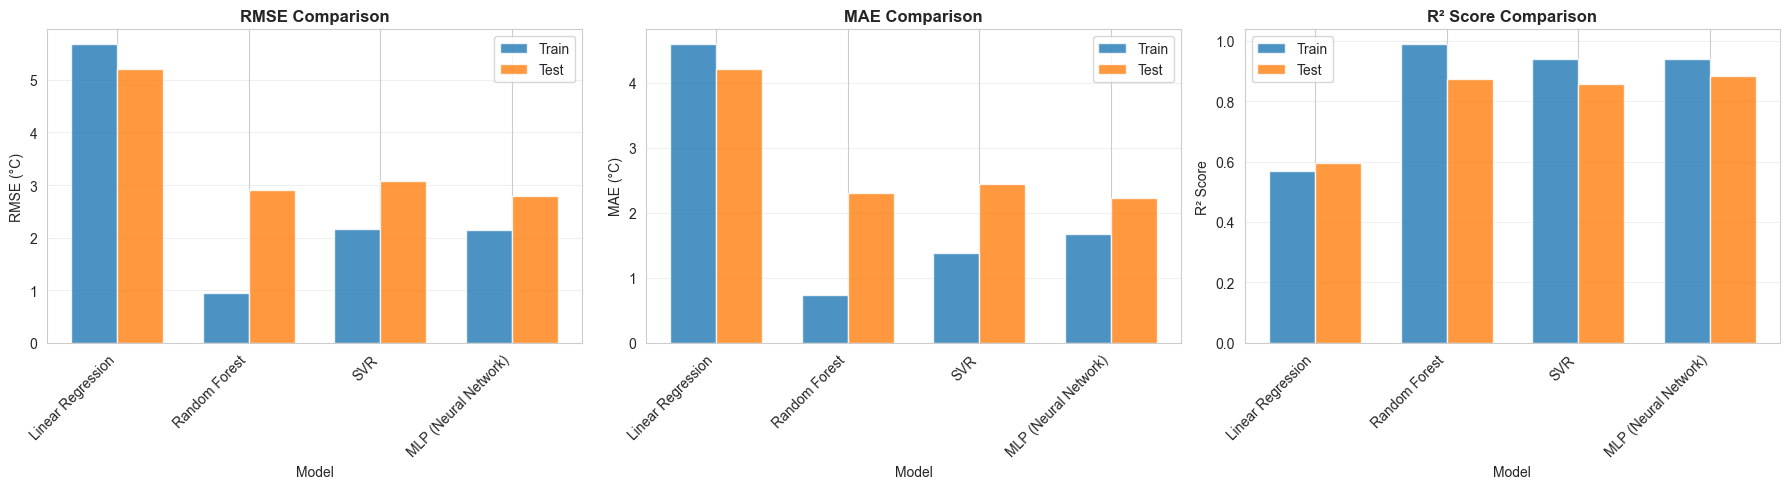

In [20]:
# Create comparison dataframe
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'SVR', 'MLP (Neural Network)'],
    'Train RMSE': [lr_train_rmse, rf_train_rmse, svr_train_rmse, mlp_train_rmse],
    'Test RMSE': [lr_test_rmse, rf_test_rmse, svr_test_rmse, mlp_test_rmse],
    'Train MAE': [lr_train_mae, rf_train_mae, svr_train_mae, mlp_train_mae],
    'Test MAE': [lr_test_mae, rf_test_mae, svr_test_mae, mlp_test_mae],
    'Train R²': [lr_train_r2, rf_train_r2, svr_train_r2, mlp_train_r2],
    'Test R²': [lr_test_r2, rf_test_r2, svr_test_r2, mlp_test_r2]
})

print('MODEL COMPARISON')
print(results.to_string(index=False))
print(f'Best Model (by Test RMSE): {results.loc[results["Test RMSE"].idxmin(), "Model"]}')
print(f'Best Test RMSE: {results["Test RMSE"].min():.3f}°C')

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# RMSE comparison
x = np.arange(len(results))
width = 0.35
axes[0].bar(x - width/2, results['Train RMSE'], width, label='Train', alpha=0.8)
axes[0].bar(x + width/2, results['Test RMSE'], width, label='Test', alpha=0.8)
axes[0].set_xlabel('Model')
axes[0].set_ylabel('RMSE (°C)')
axes[0].set_title('RMSE Comparison', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# MAE comparison
axes[1].bar(x - width/2, results['Train MAE'], width, label='Train', alpha=0.8)
axes[1].bar(x + width/2, results['Test MAE'], width, label='Test', alpha=0.8)
axes[1].set_xlabel('Model')
axes[1].set_ylabel('MAE (°C)')
axes[1].set_title('MAE Comparison', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis='y')

# R² comparison
axes[2].bar(x - width/2, results['Train R²'], width, label='Train', alpha=0.8)
axes[2].bar(x + width/2, results['Test R²'], width, label='Test', alpha=0.8)
axes[2].set_xlabel('Model')
axes[2].set_ylabel('R² Score')
axes[2].set_title('R² Score Comparison', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(results['Model'], rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

### Feature Importance (Random Forest)
**Analyzing which features are most important for prediction**

FEATURE IMPORTANCE (Random Forest)
                 Feature  Importance
                   month    0.523856
relative_humidity_2m (%)    0.332812
                    hour    0.042042
      pressure_msl (hPa)    0.029757
  wind_direction_10m (°)    0.024224
         cloud_cover (%)    0.012417
   wind_speed_10m (km/h)    0.012312
   wind_gusts_10m (km/h)    0.011383
             day_of_week    0.007058
      precipitation (mm)    0.004139


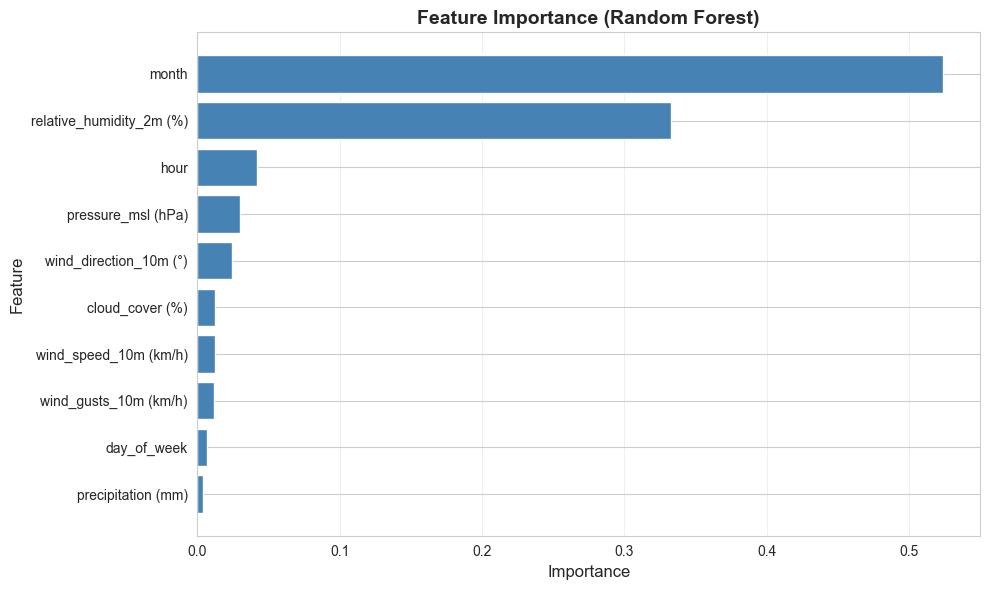

In [21]:
# Get feature importance from Random Forest
feature_importance = pd.DataFrame({
    'Feature': features_to_keep,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print('FEATURE IMPORTANCE (Random Forest)')
print(feature_importance.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance (Random Forest)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

### Actual vs Predicted (Best Model)
**Visualizing predictions vs actual values**

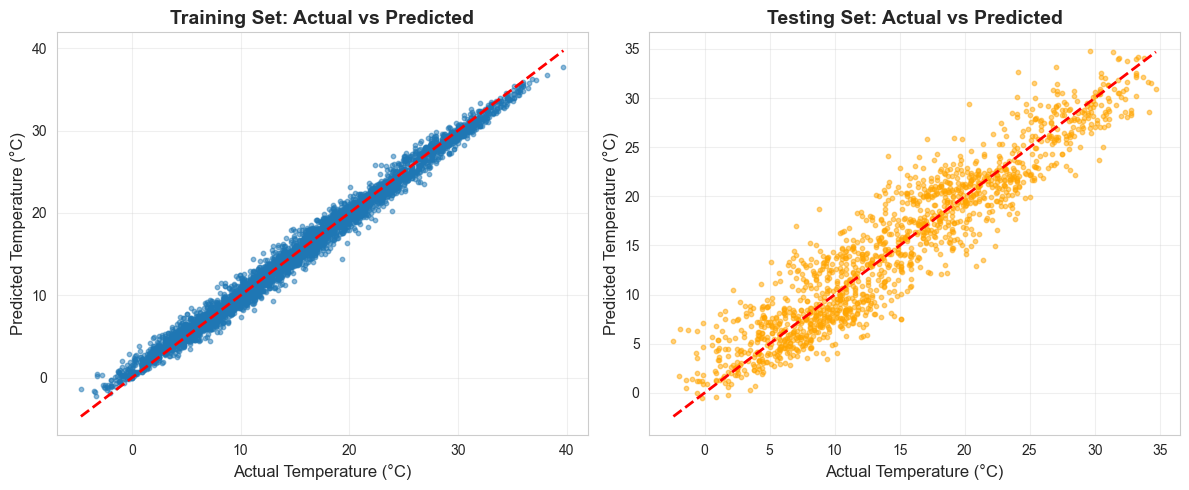

In [22]:
# Use Random Forest predictions (likely the best model)
plt.figure(figsize=(12, 5))

# Training set
plt.subplot(1, 2, 1)
plt.scatter(y_train, y_pred_rf_train, alpha=0.5, s=10)
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('Training Set: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

# Testing set
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_rf_test, alpha=0.5, s=10, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Temperature (°C)', fontsize=12)
plt.ylabel('Predicted Temperature (°C)', fontsize=12)
plt.title('Testing Set: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## TIME HORIZON FORECASTING
### Create Lagged Target Variables
**Creating 3-day, 5-day, and 7-day ahead temperature targets**

In [23]:
# Create a copy for forecasting
df_forecast = df.copy()

# Sort by time to ensure correct order
df_forecast = df_forecast.sort_values('time').reset_index(drop=True)

# Data is collected every 6 hours, so:
# 1 day = 24 hours / 6 hours = 4 observations
# 3 days = 3 * 4 = 12 observations ahead
# 5 days = 5 * 4 = 20 observations ahead
# 7 days = 7 * 4 = 28 observations ahead

# Create target variables for different horizons
df_forecast['temp_3day_ahead'] = df_forecast['temperature_2m (°C)'].shift(-12)  # 3 days
df_forecast['temp_5day_ahead'] = df_forecast['temperature_2m (°C)'].shift(-20)  # 5 days
df_forecast['temp_7day_ahead'] = df_forecast['temperature_2m (°C)'].shift(-28)  # 7 days

# Remove rows with NaN (last 28 rows won't have 7-day ahead values)
df_forecast_clean = df_forecast.dropna()

print(f'\nOriginal dataset: {len(df)} rows')
print(f'Forecast dataset: {len(df_forecast_clean)} rows (removed last 28 rows with NaN)')


Original dataset: 5844 rows
Forecast dataset: 5816 rows (removed last 28 rows with NaN)


### Train Models for Each Horizon
**Training separate models for 3-day, 5-day, and 7-day forecasts**

In [24]:
# Prepare data for forecasting
X_forecast = df_forecast_clean[features_to_keep]

# Chronological split (same as before)
train_mask_forecast = df_forecast_clean['year'] < 2024
test_mask_forecast = df_forecast_clean['year'] >= 2024

X_train_forecast = X_forecast[train_mask_forecast]
X_test_forecast = X_forecast[test_mask_forecast]

# Scale features
scaler_forecast = StandardScaler()
X_train_forecast_scaled = scaler_forecast.fit_transform(X_train_forecast)
X_test_forecast_scaled = scaler_forecast.transform(X_test_forecast)


print(f'Training samples: {X_train_forecast.shape[0]}')
print(f'Testing samples: {X_test_forecast.shape[0]}')
print(f'Features: {X_train_forecast.shape[1]}')

Training samples: 2920
Testing samples: 2896
Features: 10


In [25]:
# Dictionary to store results
results_by_horizon = {}

# Train models for each horizon
horizons = [
    ('3-day', 'temp_3day_ahead', 3),
    ('5-day', 'temp_5day_ahead', 5),
    ('7-day', 'temp_7day_ahead', 7)
]

for horizon_name, target_col, days in horizons:
    print(f'TRAINING FOR {horizon_name.upper()} HORIZON ({days} days ahead)')
    
    # Get target for this horizon
    y_train_h = df_forecast_clean.loc[train_mask_forecast, target_col]
    y_test_h = df_forecast_clean.loc[test_mask_forecast, target_col]
    
    # Train all 4 models
    models_h = {}
    
    # 1. Linear Regression
    lr_h = LinearRegression()
    lr_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['Linear Regression'] = lr_h
    
    # 2. Random Forest
    rf_h = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['Random Forest'] = rf_h
    
    # 3. SVR
    svr_h = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
    svr_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['SVR'] = svr_h
    
    # 4. MLP
    mlp_h = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
    mlp_h.fit(X_train_forecast_scaled, y_train_h)
    models_h['MLP'] = mlp_h
    
    # Evaluate all models
    horizon_results = []
    for model_name, model in models_h.items():
        y_pred_train_h = model.predict(X_train_forecast_scaled)
        y_pred_test_h = model.predict(X_test_forecast_scaled)
        
        train_rmse_h = np.sqrt(mean_squared_error(y_train_h, y_pred_train_h))
        test_rmse_h = np.sqrt(mean_squared_error(y_test_h, y_pred_test_h))
        train_mae_h = mean_absolute_error(y_train_h, y_pred_train_h)
        test_mae_h = mean_absolute_error(y_test_h, y_pred_test_h)
        train_r2_h = r2_score(y_train_h, y_pred_train_h)
        test_r2_h = r2_score(y_test_h, y_pred_test_h)
        
        horizon_results.append({
            'Model': model_name,
            'Train RMSE': train_rmse_h,
            'Test RMSE': test_rmse_h,
            'Train MAE': train_mae_h,
            'Test MAE': test_mae_h,
            'Train R²': train_r2_h,
            'Test R²': test_r2_h
        })
    
    # Store results
    results_df_h = pd.DataFrame(horizon_results)
    results_by_horizon[horizon_name] = {
        'results': results_df_h,
        'models': models_h,
        'y_test': y_test_h,
        'X_test_scaled': X_test_forecast_scaled
    }
    
    # Print results
    print(f'\nResults for {horizon_name} horizon:')
    print(results_df_h.to_string(index=False))
    print(f'\nBest Model: {results_df_h.loc[results_df_h["Test RMSE"].idxmin(), "Model"]}')
    print(f'Best Test RMSE: {results_df_h["Test RMSE"].min():.3f}°C')


TRAINING FOR 3-DAY HORIZON (3 days ahead)

Results for 3-day horizon:
            Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression    6.246957   6.058283   5.087201  4.938087  0.478354 0.478656
    Random Forest    1.120452   3.321989   0.874732  2.637241  0.983219 0.843245
              SVR    2.453416   3.880356   1.573138  3.067338  0.919540 0.786121
              MLP    2.436368   3.557235   1.919739  2.846525  0.920654 0.820258

Best Model: Random Forest
Best Test RMSE: 3.322°C
TRAINING FOR 5-DAY HORIZON (5 days ahead)

Results for 5-day horizon:
            Model  Train RMSE  Test RMSE  Train MAE  Test MAE  Train R²  Test R²
Linear Regression    6.345085   6.179777   5.176989  5.002383  0.462093 0.460092
    Random Forest    1.111883   3.471936   0.862275  2.733368  0.983482 0.829581
              SVR    2.524101   4.121164   1.616515  3.233958  0.914877 0.759888
              MLP    2.500209   3.708018   1.978568  2.943581  0.916481 0.805617

### Compare Performance Across Horizons
**Comparing how accuracy changes with forecast horizon**


Horizon    Best Model  Test RMSE (°C)  Test MAE (°C)  Test R²
  3-day Random Forest        3.321989       2.637241 0.843245
  5-day Random Forest        3.471936       2.733368 0.829581
  7-day Random Forest        3.534435       2.806590 0.824137


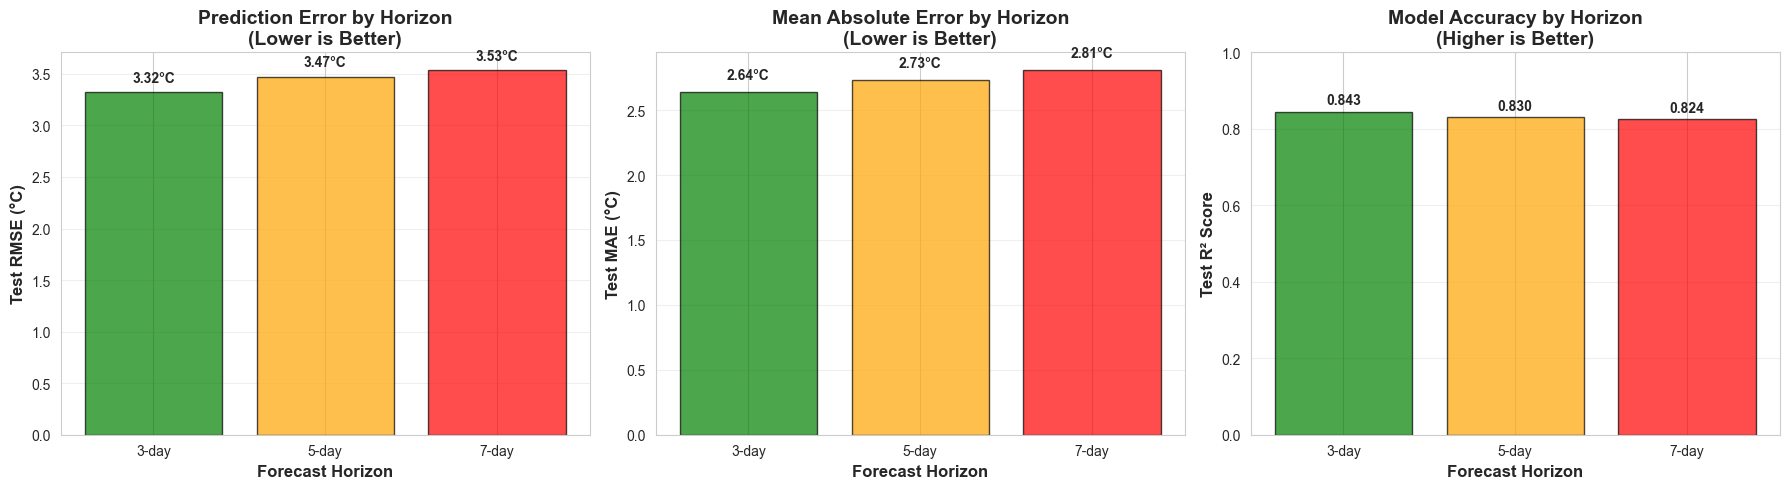

In [26]:
# Get best model for each horizon
comparison_data = []
for horizon_name in ['3-day', '5-day', '7-day']:
    results_df = results_by_horizon[horizon_name]['results']
    best_idx = results_df['Test RMSE'].idxmin()
    best_model = results_df.loc[best_idx, 'Model']
    best_rmse = results_df.loc[best_idx, 'Test RMSE']
    best_mae = results_df.loc[best_idx, 'Test MAE']
    best_r2 = results_df.loc[best_idx, 'Test R²']
    
    comparison_data.append({
        'Horizon': horizon_name,
        'Best Model': best_model,
        'Test RMSE (°C)': best_rmse,
        'Test MAE (°C)': best_mae,
        'Test R²': best_r2
    })

comparison_df = pd.DataFrame(comparison_data)
print('\n' + comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

horizons_list = ['3-day', '5-day', '7-day']
colors = ['green', 'orange', 'red']

# RMSE comparison
axes[0].bar(horizons_list, comparison_df['Test RMSE (°C)'], color=colors, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Test RMSE (°C)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[0].set_title('Prediction Error by Horizon\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Test RMSE (°C)']):
    axes[0].text(i, v + 0.1, f'{v:.2f}°C', ha='center', fontweight='bold')

# MAE comparison
axes[1].bar(horizons_list, comparison_df['Test MAE (°C)'], color=colors, alpha=0.7, edgecolor='black')
axes[1].set_ylabel('Test MAE (°C)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[1].set_title('Mean Absolute Error by Horizon\n(Lower is Better)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Test MAE (°C)']):
    axes[1].text(i, v + 0.1, f'{v:.2f}°C', ha='center', fontweight='bold')

# R² comparison
axes[2].bar(horizons_list, comparison_df['Test R²'], color=colors, alpha=0.7, edgecolor='black')
axes[2].set_ylabel('Test R² Score', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Forecast Horizon', fontsize=12, fontweight='bold')
axes[2].set_title('Model Accuracy by Horizon\n(Higher is Better)', fontsize=14, fontweight='bold')
axes[2].set_ylim([0, 1])
axes[2].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(comparison_df['Test R²']):
    axes[2].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

---
## SUMMARY & NEXT STEPS
### Complete Project Summary
**NOTE: UPDATED CELL - Summary including horizon forecasting**

In [27]:
print('\n PART 1: SAME-TIME PREDICTION RESULTS')
print('-' * 70)
print(f'Dataset: {df.shape[0]} samples, {len(features_to_keep)} features')
print(f'Training samples: {X_train.shape[0]} (2022-2023)')
print(f'Testing samples: {X_test.shape[0]} (2024-2025)')
print(f'\nBest Model: {results.loc[results["Test RMSE"].idxmin(), "Model"]}')
print(f'Best Test RMSE: {results["Test RMSE"].min():.3f}°C')
print(f'Best Test R²: {results.loc[results["Test RMSE"].idxmin(), "Test R²"]:.3f}')
print('\nPART 2: HORIZON FORECASTING RESULTS')
print('-' * 70)
for horizon_name in ['3-day', '5-day', '7-day']:
    results_df = results_by_horizon[horizon_name]['results']
    best_idx = results_df['Test RMSE'].idxmin()
    best_model = results_df.loc[best_idx, 'Model']
    best_rmse = results_df.loc[best_idx, 'Test RMSE']
    best_r2 = results_df.loc[best_idx, 'Test R²']
    print(f'{horizon_name} forecast: {best_model} - RMSE: {best_rmse:.3f}°C, R²: {best_r2:.3f}')


 PART 1: SAME-TIME PREDICTION RESULTS
----------------------------------------------------------------------
Dataset: 5844 samples, 10 features
Training samples: 4384 (2022-2023)
Testing samples: 1460 (2024-2025)

Best Model: MLP (Neural Network)
Best Test RMSE: 2.785°C
Best Test R²: 0.884

PART 2: HORIZON FORECASTING RESULTS
----------------------------------------------------------------------
3-day forecast: Random Forest - RMSE: 3.322°C, R²: 0.843
5-day forecast: Random Forest - RMSE: 3.472°C, R²: 0.830
7-day forecast: Random Forest - RMSE: 3.534°C, R²: 0.824


missing stuff:
hyperparameter optimization
